## Hucira - cytokine signalling comparing iML and cNK cells in tumor vs normal in lung matched data

In [51]:
#hucira env
#in terminal

#conda create -n hucira-env python=3.12
#conda activate hucira-env
#pip install git+https://github.com/theislab/huCIRA.git
#pip install ipykernel
#python -m ipykernel install --user --name hucira-env --display-name "Python (hucira)"

In [52]:
# https://github.com/theislab/huCIRA/blob/main/docs/notebooks/Tutorial_huCIRA_Lupus_hcd.ipynb
# https://github.com/theislab/huCIRA/blob/main/docs/notebooks/advanced_tutorial_full_pipeline.ipynb

In [164]:
import time
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from tqdm import TqdmWarning
import hucira as hc
warnings.simplefilter("ignore", TqdmWarning)
start = time.time()

In [165]:
#### Load the human cytokine dictionary

df_hcd_all = hc.load_human_cytokine_dict(save_dir="/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/hucira")

print(f"All celltypes in dictionary:\n  {df_hcd_all.celltype.unique()}")
print("\n")
print(f"All cytokines in dictionary:\n  {df_hcd_all.cytokine.unique()}")

df_hcd_all.head()

Loading from: /Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/hucira/human_cytokine_dict.csv


All celltypes in dictionary:
  ['Intermediate_B_cell' 'NKT' 'CD8_Memory_T_cell' 'NK_CD56low' 'CD16_Mono'
 'NK_CD56hi' 'CD8_Naive_T_cell' 'pDC' 'ILC' 'MAIT' 'Naive_B_cell'
 'CD4_Naive_T_cell' 'Treg' 'Plasmablast' 'Granulocyte' 'B_cell'
 'CD4_T_cell' 'HSPC' 'CD8_T_cell' 'CD14_Mono' 'cDC' 'CD4_Memory_T_cell'
 'NK' 'Mono']


All cytokines in dictionary:
  ['4-1BBL' 'ADSF' 'APRIL' 'BAFF' 'C5a' 'CD27L' 'CD30L' 'CD40L' 'CT-1'
 'Decorin' 'EGF' 'EPO' 'FGF-beta' 'FLT3L' 'FasL' 'G-CSF' 'GDNF' 'GITRL'
 'GM-CSF' 'HGF' 'IFN-alpha1' 'IFN-beta' 'IFN-epsilon' 'IFN-gamma'
 'IFN-lambda1' 'IFN-lambda2' 'IFN-lambda3' 'IFN-omega' 'IGF-1'
 'IL-1-alpha' 'IL-1-beta' 'IL-10' 'IL-11' 'IL-12' 'IL-13' 'IL-15' 'IL-16'
 'IL-17A' 'IL-17B' 'IL-17C' 'IL-17D' 'IL-17E' 'IL-17F' 'IL-19' 'IL-1Ra'
 'IL-2' 'IL-20' 'IL-21' 'IL-22' 'IL-23' 'IL-24' 'IL-26' 'IL-27' 'IL-3'
 'IL-31' 'IL-32-beta' 'IL-33' 'IL-34' 'IL-35' 'IL-36-alpha' 'IL-36Ra'
 'IL-4' 'IL-5' 'IL-6' 'IL-7' 'IL-8' 'IL-9' 'LIF' 'LIGHT' 'LT-alpha1-beta2'
 'LT-alpha2-be

,gene,log_fc,logCPM,F,p_value,adj_p_value,contrast,celltype,cytokine,num_donors,median_num_cells_pbs,median_num_cells_cytokine,mean_num_cells_pbs,mean_num_cells_cytokine,min_num_cells_pbs,min_num_cells_cytokine,max_num_cells_pbs,max_num_cells_cytokine,num_DE_pbs_wells,well_biased
0,A1BG-AS1,-0.238704,3.888135,3.040818,0.093012,0.433379,NaN,Intermediate_B_cell,4-1BBL,12.0,1435.5,215.5,1814.333333,307.166667,367.0,60.0,4609.0,864.0,0.0,False
1,A1BG-AS1,-0.077966,3.918833,0.396225,0.535585,0.791563,NaN,Intermediate_B_cell,ADSF,12.0,1435.5,264.0,1814.333333,299.750000,367.0,53.0,4609.0,692.0,0.0,False
2,A1BG-AS1,-0.208858,3.911595,2.522081,0.124235,0.408307,NaN,Intermediate_B_cell,APRIL,12.0,1435.5,167.0,1814.333333,195.166667,367.0,55.0,4609.0,482.0,0.0,False
3,A1BG-AS1,-0.293355,3.897822,6.232523,0.019998,0.098003,NaN,Intermediate_B_cell,BAFF,12.0,1435.5,203.5,1814.333333,209.250000,367.0,74.0,4609.0,450.0,2.0,False
4,A1BG-AS1,-0.304181,3.880107,7.867570,0.010094,0.106723,NaN,Intermediate_B_cell,C5a,12.0,1435.5,193.5,1814.333333,214.750000,367.0,56.0,4609.0,376.0,1.0,False


In [166]:
#### Load the query adata object

#adata = hc.load_lupus_data()
adata = sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")
adata

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [168]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [169]:
# Count unique sources per patient
patient_source_counts = adata.obs.groupby("patient_ID_v2")["source"].nunique()

# Identify patients with >1 unique source
patients_multiple_sources = patient_source_counts[patient_source_counts > 1].index

# Filter adata to only include those patients
adata_filtered = adata[adata.obs["patient_ID_v2"].isin(patients_multiple_sources)].copy()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_72948/1508113905.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_source_counts = adata.obs.groupby("patient_ID_v2")["source"].nunique()


In [170]:
adata_filtered.obs["patient_ID_v2"].nunique()

77

In [ ]:
# subset to include only matched lung data

In [171]:
adata_lung = adata_filtered[adata_filtered.obs["source"].isin(["lung_normal", "lung_tumor"])].copy()

In [172]:
adata_lung

AnnData object with n_obs × n_vars = 31932 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [173]:
adata_lung.obs["patient_ID_v2"].nunique()

61

In [174]:
adata_lung.obs["source"].value_counts()

source
lung_normal    20361
lung_tumor     11571
Name: count, dtype: int64

In [175]:
adata_lung = adata_lung[adata_lung.obs['classification'] != 'unclassified'].copy()
adata_lung.obs['classification_v2'] = adata_lung.obs['classification'].replace({
    'CD56bright': 'cNK',
    'CD56dim': 'cNK',
    'ML1': 'iML',
    'ML2': 'iML',
    'ML_transition': 'iML'
})
adata_lung.obs['classification'] = adata_lung.obs['classification'].astype('category')

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_72948/1816853696.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_lung.obs['classification_v2'] = adata_lung.obs['classification'].replace({


In [176]:
adata_lung.obs["classification_v2"].value_counts()

classification_v2
cNK    28257
iML     3328
Name: count, dtype: int64

In [177]:
#### For easy workflow:
# Enter celltype column name and condition column name
your_celltype_colname = "classification_v2"
your_contrast_colname = "source"

# Check data size (Are the conditions you want to contrast of comparable size?)
adata_lung.obs[your_contrast_colname].value_counts()

source
lung_normal    20237
lung_tumor     11348
Name: count, dtype: int64

In [178]:
# Enrichment analysis needs two main information from query adata_lung: cell types and disease conditions.
# They have to be chosen manually, because annotation of objects differs.

print(f"All celltypes in query data:\n  {sorted(adata_lung.obs[your_celltype_colname].unique())}\n")
print(f"All experimental states (contrasts/conditions) in query data:\n  {sorted(adata_lung.obs[your_contrast_colname].unique())}\n")

All celltypes in query data:
  ['cNK', 'iML']

All experimental states (contrasts/conditions) in query data:
  ['lung_normal', 'lung_tumor']



In [179]:
print(adata_lung.raw)        # likely None
print(adata_lung.X)          # check current X
print(adata_lung.layers.keys())  # check available layers

None
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23152890 stored elements and shape (31585, 14337)>
  Coords	Values
  (0, 14317)	1.0
  (0, 14301)	1.0
  (0, 14248)	1.0
  (0, 14202)	1.0
  (0, 14187)	1.0
  (0, 14160)	1.0
  (0, 14137)	1.0
  (0, 14129)	1.0
  (0, 14121)	1.0
  (0, 14113)	1.0
  (0, 14091)	1.0
  (0, 14089)	2.0
  (0, 14081)	1.0
  (0, 14072)	2.0
  (0, 14050)	1.0
  (0, 14042)	1.0
  (0, 14040)	1.0
  (0, 14013)	1.0
  (0, 14009)	2.0
  (0, 14003)	1.0
  (0, 14000)	2.0
  (0, 13971)	1.0
  (0, 13963)	2.0
  (0, 13955)	2.0
  (0, 13928)	1.0
  :	:
  (31584, 492)	1.0
  (31584, 433)	1.0
  (31584, 404)	2.0
  (31584, 395)	2.0
  (31584, 394)	2.0
  (31584, 367)	1.0
  (31584, 332)	1.0
  (31584, 298)	1.0
  (31584, 276)	3.0
  (31584, 255)	1.0
  (31584, 254)	1.0
  (31584, 251)	4.0
  (31584, 249)	3.0
  (31584, 235)	1.0
  (31584, 234)	2.0
  (31584, 213)	1.0
  (31584, 198)	1.0
  (31584, 174)	1.0
  (31584, 157)	1.0
  (31584, 155)	1.0
  (31584, 107)	1.0
  (31584, 86)	1.0
  (31584, 25)	2.0


In [180]:
#### Query data needs to be pre-processed

adata_lung.layers["counts"] = adata_lung.X 
adata_lung.layers["scaled_original_counts"] = adata_lung.X
adata_lung.X = adata_lung.layers["counts"]

# Basic quality checks:
sc.pp.filter_cells(adata_lung, min_genes=200)
sc.pp.filter_genes(adata_lung, min_cells=3)

# Log-normalize:
sc.pp.normalize_total(adata_lung)
sc.pp.log1p(adata_lung)

adata_lung

AnnData object with n_obs × n_vars = 31493 × 13357
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification', 'classification_v2', 'n_genes'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap'
    layer

In [181]:
#import sys
#!{sys.executable} -m pip install mygene

In [182]:
# Genes are already gene symbols - no conversion needed
adata_lung.var["gene_symbol"] = adata_lung.var_names

# 1. Remove any genes with missing names
keep_idx = ~adata_lung.var["gene_symbol"].isna()
adata_lung = adata_lung[:, keep_idx].copy()

# 2. Identify duplicate gene symbols
dup_idx = adata_lung.var["gene_symbol"].duplicated(keep="first")

# 3. Keep only the first occurrence of each gene symbol
adata_lung = adata_lung[:, ~dup_idx].copy()

# 4. Set gene_symbol as the new var index
adata_lung.var_names = adata_lung.var["gene_symbol"]
adata_lung.var_names_make_unique()

print(adata_lung.var_names[:5])  # verify
print(adata_lung.shape)

Index(['LINC00115', 'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17'], dtype='object', name='gene_symbol')
(31493, 13357)


In [183]:
print(df_hcd_all.celltype.unique())

['Intermediate_B_cell' 'NKT' 'CD8_Memory_T_cell' 'NK_CD56low' 'CD16_Mono'
 'NK_CD56hi' 'CD8_Naive_T_cell' 'pDC' 'ILC' 'MAIT' 'Naive_B_cell'
 'CD4_Naive_T_cell' 'Treg' 'Plasmablast' 'Granulocyte' 'B_cell'
 'CD4_T_cell' 'HSPC' 'CD8_T_cell' 'CD14_Mono' 'cDC' 'CD4_Memory_T_cell'
 'NK' 'Mono']


In [184]:
#### Create celltype_combos. An input parameter for the enrichment analysis.

adata_celltypes = [ "cNK", "iML",]
hcd_celltypes = [ "NK", "NK",]
celltype_combos = hc.create_celltype_combos(adata_celltypes, hcd_celltypes)
print(celltype_combos)

[('cNK', 'NK'), ('iML', 'NK')]


In [185]:
#### Define conditions of interest:
contrasts = [("lung_tumor", "lung_normal")]

In [ ]:
# running enrichment analyses across multiple cell types

In [186]:
enrichment_results = hc.run_all_enrichment_test(
    adata=adata_lung,
    df=df_hcd_all,
    contrasts_combo=("lung_tumor", "lung_normal"),
    celltype_combos=celltype_combos,
    contrast_column=your_contrast_colname,
    celltype_column=your_celltype_colname,
    # The following parameters are optional (they have default specifications)
    direction="upregulated",
    # Filtering parameters for gene set construction (of dictionary or gene program)
    threshold_lfc=[0.5, 0.75, 1.0],
    threshold_expression=0.05,
    threshold_pval=0.01,
    # GSEA parameters
    min_size=10,
    max_size=1000,
    permutation_num=1000,
    weight=1.0,
    seed=2025,
    ranking_statistic_fn=None,)

Computing gene sets of Human Cytokine Dictionary for NK.
Running enrichment for contrast: lung_tumor_vs_lung_normal
Computing gene sets of Human Cytokine Dictionary for NK.
Running enrichment for contrast: lung_tumor_vs_lung_normal
Computing gene sets of Human Cytokine Dictionary for NK.
Running enrichment for contrast: lung_tumor_vs_lung_normal
Computing gene sets of Human Cytokine Dictionary for NK.
Running enrichment for contrast: lung_tumor_vs_lung_normal
Computing gene sets of Human Cytokine Dictionary for NK.
Running enrichment for contrast: lung_tumor_vs_lung_normal
Computing gene sets of Human Cytokine Dictionary for NK.
Running enrichment for contrast: lung_tumor_vs_lung_normal


In [187]:
# Look at all enrichment results (reduced view to columns of interest, not all statistics)
enrichment_results[
    [   "celltype_combo",
        "cytokine",
        "contrast",
        "direction",
        "ES",
        "NES",
        "NOM p-val",
        "FDR q-val",
        "FWER p-val",
        "frac_shared_genes_signature",
        "Lead_genes",
        "threshold_lfc",
        "threshold_expression",
    ]
].sort_values("NES", ascending=False).head()

,celltype_combo,cytokine,contrast,direction,ES,NES,NOM p-val,FDR q-val,FWER p-val,frac_shared_genes_signature,Lead_genes,threshold_lfc,threshold_expression
0,iML (NK),IL-32-beta,lung_tumor_vs_lung_normal,upregulated,0.730171,2.571186,0.0,0.0,0.0,0.275000,CXCR4;DUSP4;ITGA1;ITM2C;RGCC;TNFRSF18;ENTPD1;D...,0.75,0.05
0,iML (NK),IL-32-beta,lung_tumor_vs_lung_normal,upregulated,0.65113,2.539736,0.0,0.0,0.0,0.293151,JUN;CXCR4;DUSP4;ITGA1;ITM2C;RGCC;TNFRSF18;RGS2...,0.50,0.05
0,iML (NK),IL-32-beta,lung_tumor_vs_lung_normal,upregulated,0.832275,2.496025,0.0,0.0,0.0,0.228814,CXCR4;DUSP4;ITGA1;ITM2C;TNFRSF18;ENTPD1;DDIT4;...,1.00,0.05
1,iML (NK),IL-7,lung_tumor_vs_lung_normal,upregulated,0.540589,2.01229,0.0,0.000955,0.001,0.243553,RGS1;CSF1;HSPE1;HSPD1;DNAJA1;HSP90AB1;NAMPT;CO...,0.50,0.05
2,iML (NK),IL-12,lung_tumor_vs_lung_normal,upregulated,0.538377,1.962905,0.0,0.001911,0.003,0.394118,TNFRSF18;HSPE1;HSP90AA1;HSPD1;ENTPD1;GZMA;HSP9...,0.50,0.05


In [188]:
enrichment_results

,Name,cytokine,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,...,threshold_expression,min_size,max_size,permutation_num,weight,seed,threads,num_genes_signature,num_shared_genes_signature,frac_shared_genes_signature
0,prerank,IL-32-beta,-0.441141,-1.460708,0.007415,0.58893,0.409,27/80,17.03%,METRNL;NR4A2;PDE4D;BPGM;ITPRIP;ETS1;SYTL3;FYN;...,...,0.05,10,1000,1000,1.0,2025,6,365.0,80.0,0.219178
1,prerank,IL-4,-0.45441,-1.358065,0.066521,0.674304,0.651,30/42,37.93%,NFATC3;PIP4K2A;STK17B;CD55;HIPK2;RNF125;LRRFIP...,...,0.05,10,1000,1000,1.0,2025,6,233.0,42.0,0.180258
2,prerank,IL-3,-0.504217,-1.282631,0.145522,0.771607,0.83,5/15,17.18%,CD74;MAT2A;TBX21;HLA-B;HSPA8,...,0.05,10,1000,1000,1.0,2025,6,47.0,15.0,0.319149
3,prerank,IL-1Ra,-0.522139,-1.259811,0.1772,0.677883,0.868,8/12,34.82%,METRNL;MOAP1;RASGRP2;SLC3A2;CREBZF;PITHD1;DEDD...,...,0.05,10,1000,1000,1.0,2025,6,29.0,12.0,0.413793
4,prerank,IL-27,-0.43562,-1.207528,0.208575,0.763564,0.943,10/24,24.22%,IRF1;DNAJA1;CD74;APOL6;HSPA8;GCH1;HLA-DPA1;MTH...,...,0.05,10,1000,1000,1.0,2025,6,79.0,24.0,0.303797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,prerank,IFN-beta,0.43569,1.576339,0.015038,0.033596,0.038,28/68,19.10%,RGS1;CSF1;NAMPT;OASL;GBP5;ANXA5;TIPARP;ISG15;G...,...,0.05,10,1000,1000,1.0,2025,6,232.0,68.0,0.293103
3,prerank,IFN-gamma,0.488534,1.42821,0.070615,0.071992,0.096,7/24,9.64%,RGS1;CSF1;GBP5;TYMP;EPSTI1;GBP1;DUSP5,...,0.05,10,1000,1000,1.0,2025,6,63.0,24.0,0.380952
4,prerank,IL-2,0.328745,1.383179,0.022277,0.080631,0.128,45/179,13.03%,DUSP4;HSPH1;TNFRSF18;CSF1;HSPE1;HSP90AA1;HSPD1...,...,0.05,10,1000,1000,1.0,2025,6,567.0,179.0,0.315697
5,prerank,IL-15,0.305429,1.308789,0.020619,0.106788,0.193,63/212,15.63%,HSPH1;TNFRSF18;CSF1;HSPE1;HSP90AA1;HSPD1;GZMA;...,...,0.05,10,1000,1000,1.0,2025,6,756.0,212.0,0.280423


In [ ]:
# Checking for cytokines which are robustly significant and associated irt iML and cNK in tumor and normal

In [203]:
robust_results = hc.check_robustness(
    enrichment_results,
    threshold_qval=0.05,  # direct impact on NES results: filters FDR q-val
    threshold_valid=0.4,
    threshold_below_alpha=0.6,
)
robust_results

100%|██████████| 1/1 [00:00<00:00, 12.27it/s]


,celltype_combo,contrast,cytokine,frac_valid,frac_significant,is_robust,NES_min,NES_max,qval_threshold,threshold_frac_below_alpha
0,iML (NK),lung_tumor_vs_lung_normal,IL-32-beta,1.000000,1.0,True,2.496025,2.571186,0.05,0.6
1,iML (NK),lung_tumor_vs_lung_normal,IL-7,0.666667,1.0,True,1.838142,2.012290,0.05,0.6
2,iML (NK),lung_tumor_vs_lung_normal,IL-12,0.666667,1.0,True,1.758030,1.962905,0.05,0.6
3,iML (NK),lung_tumor_vs_lung_normal,IL-27,0.666667,1.0,True,1.574232,1.650507,0.05,0.6


In [206]:
robust_results = hc.get_robust_significant_results(
    results=enrichment_results,
    alphas=[0.1, 0.05, 0.01],
    threshold_valid=0.1,
    threshold_below_alpha=0.9
)

100%|██████████| 1/1 [00:00<00:00, 16.81it/s]
Contrast: lung_tumor_vs_lung_normal


celltype_combo,cNK (NK),iML (NK)
cytokine,,
BAFF,-0.926196,1.086607
GM-CSF,-0.614837,1.808493
IFN-alpha1,-0.867057,0.942595
IFN-beta,-0.800025,1.462526
IFN-gamma,-0.795466,1.439195
IFN-lambda3,-1.166549,-1.209759
IFN-omega,-0.891792,1.411652
IL-1-alpha,-0.985209,1.554121
IL-1-beta,-0.836969,1.453101


Contrast that was plotted in this example: lung_tumor_vs_lung_normal


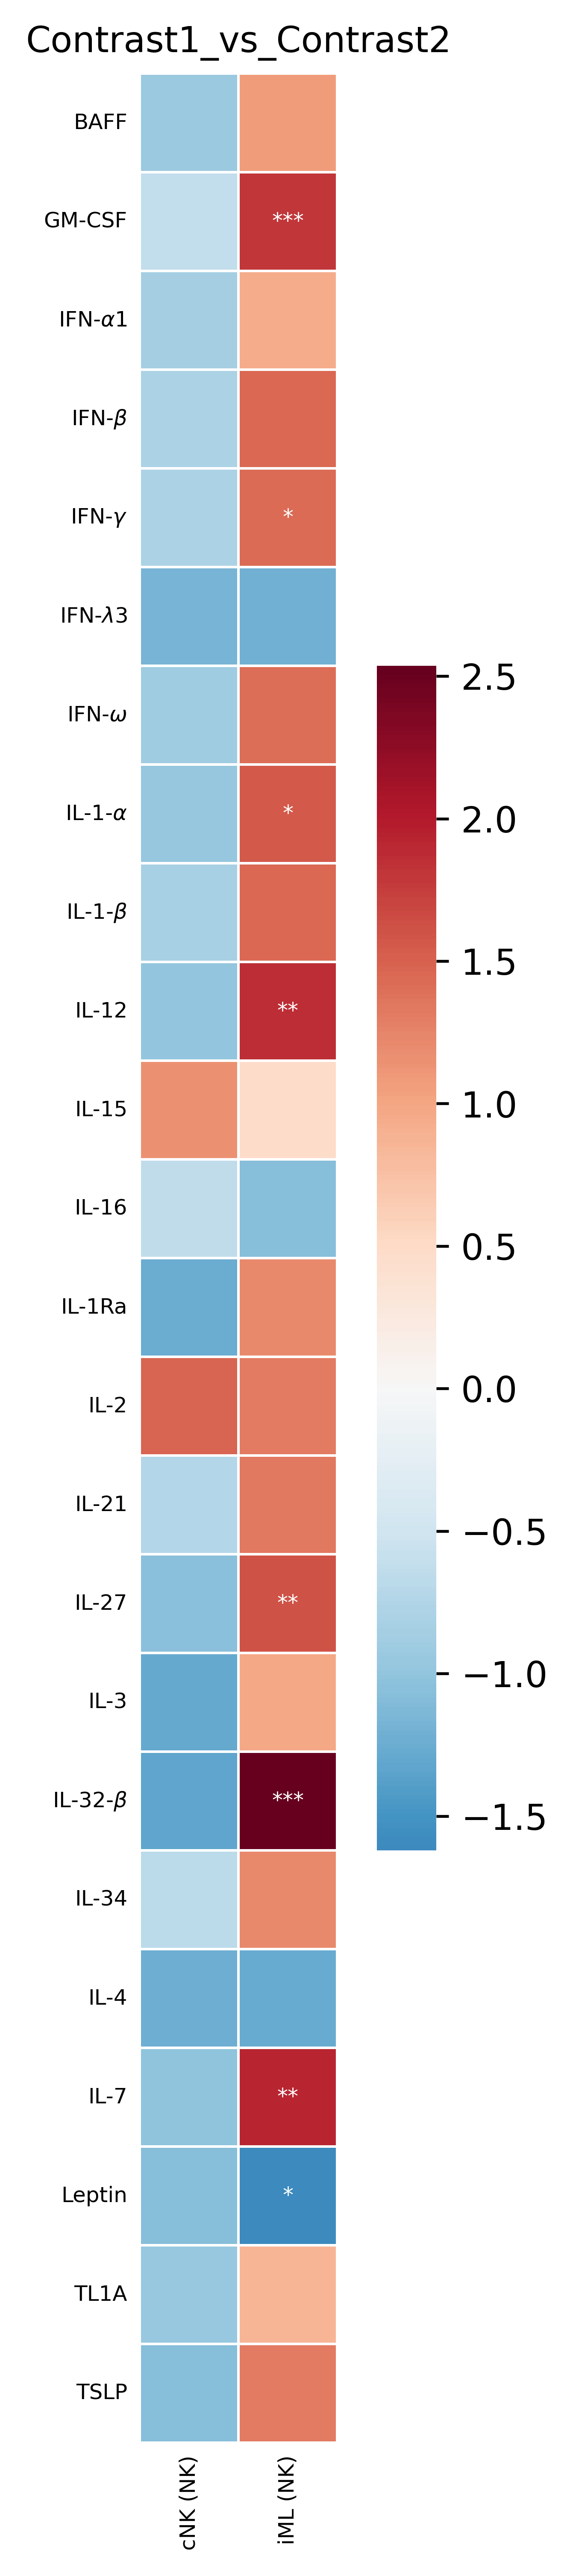

In [210]:
contrast_one = enrichment_results.contrast.unique()[0]  # Can be looked up manually
print(f"Contrast that was plotted in this example: {contrast_one}")

hc.plot_significant_results(
    results_pivot=robust_results[contrast_one][0],
    df_annot=robust_results[contrast_one][1],
    fontsize=6,
    save_fig=False,
    fig_path="",
)

In [ ]:
plt.rcParams['figure.dpi'] = 600

In [ ]:
# Selecting and plotting only robustly significant cytokines resulted from check_robustness() function

Available cytokines:
['BAFF', 'GM-CSF', 'IFN-alpha1', 'IFN-beta', 'IFN-gamma', 'IFN-lambda3', 'IFN-omega', 'IL-1-alpha', 'IL-1-beta', 'IL-12', 'IL-15', 'IL-16', 'IL-1Ra', 'IL-2', 'IL-21', 'IL-27', 'IL-3', 'IL-32-beta', 'IL-34', 'IL-4', 'IL-7', 'Leptin', 'TL1A', 'TSLP']
Matched cytokines: ['IL-12', 'IL-27', 'IL-32-beta', 'IL-7']


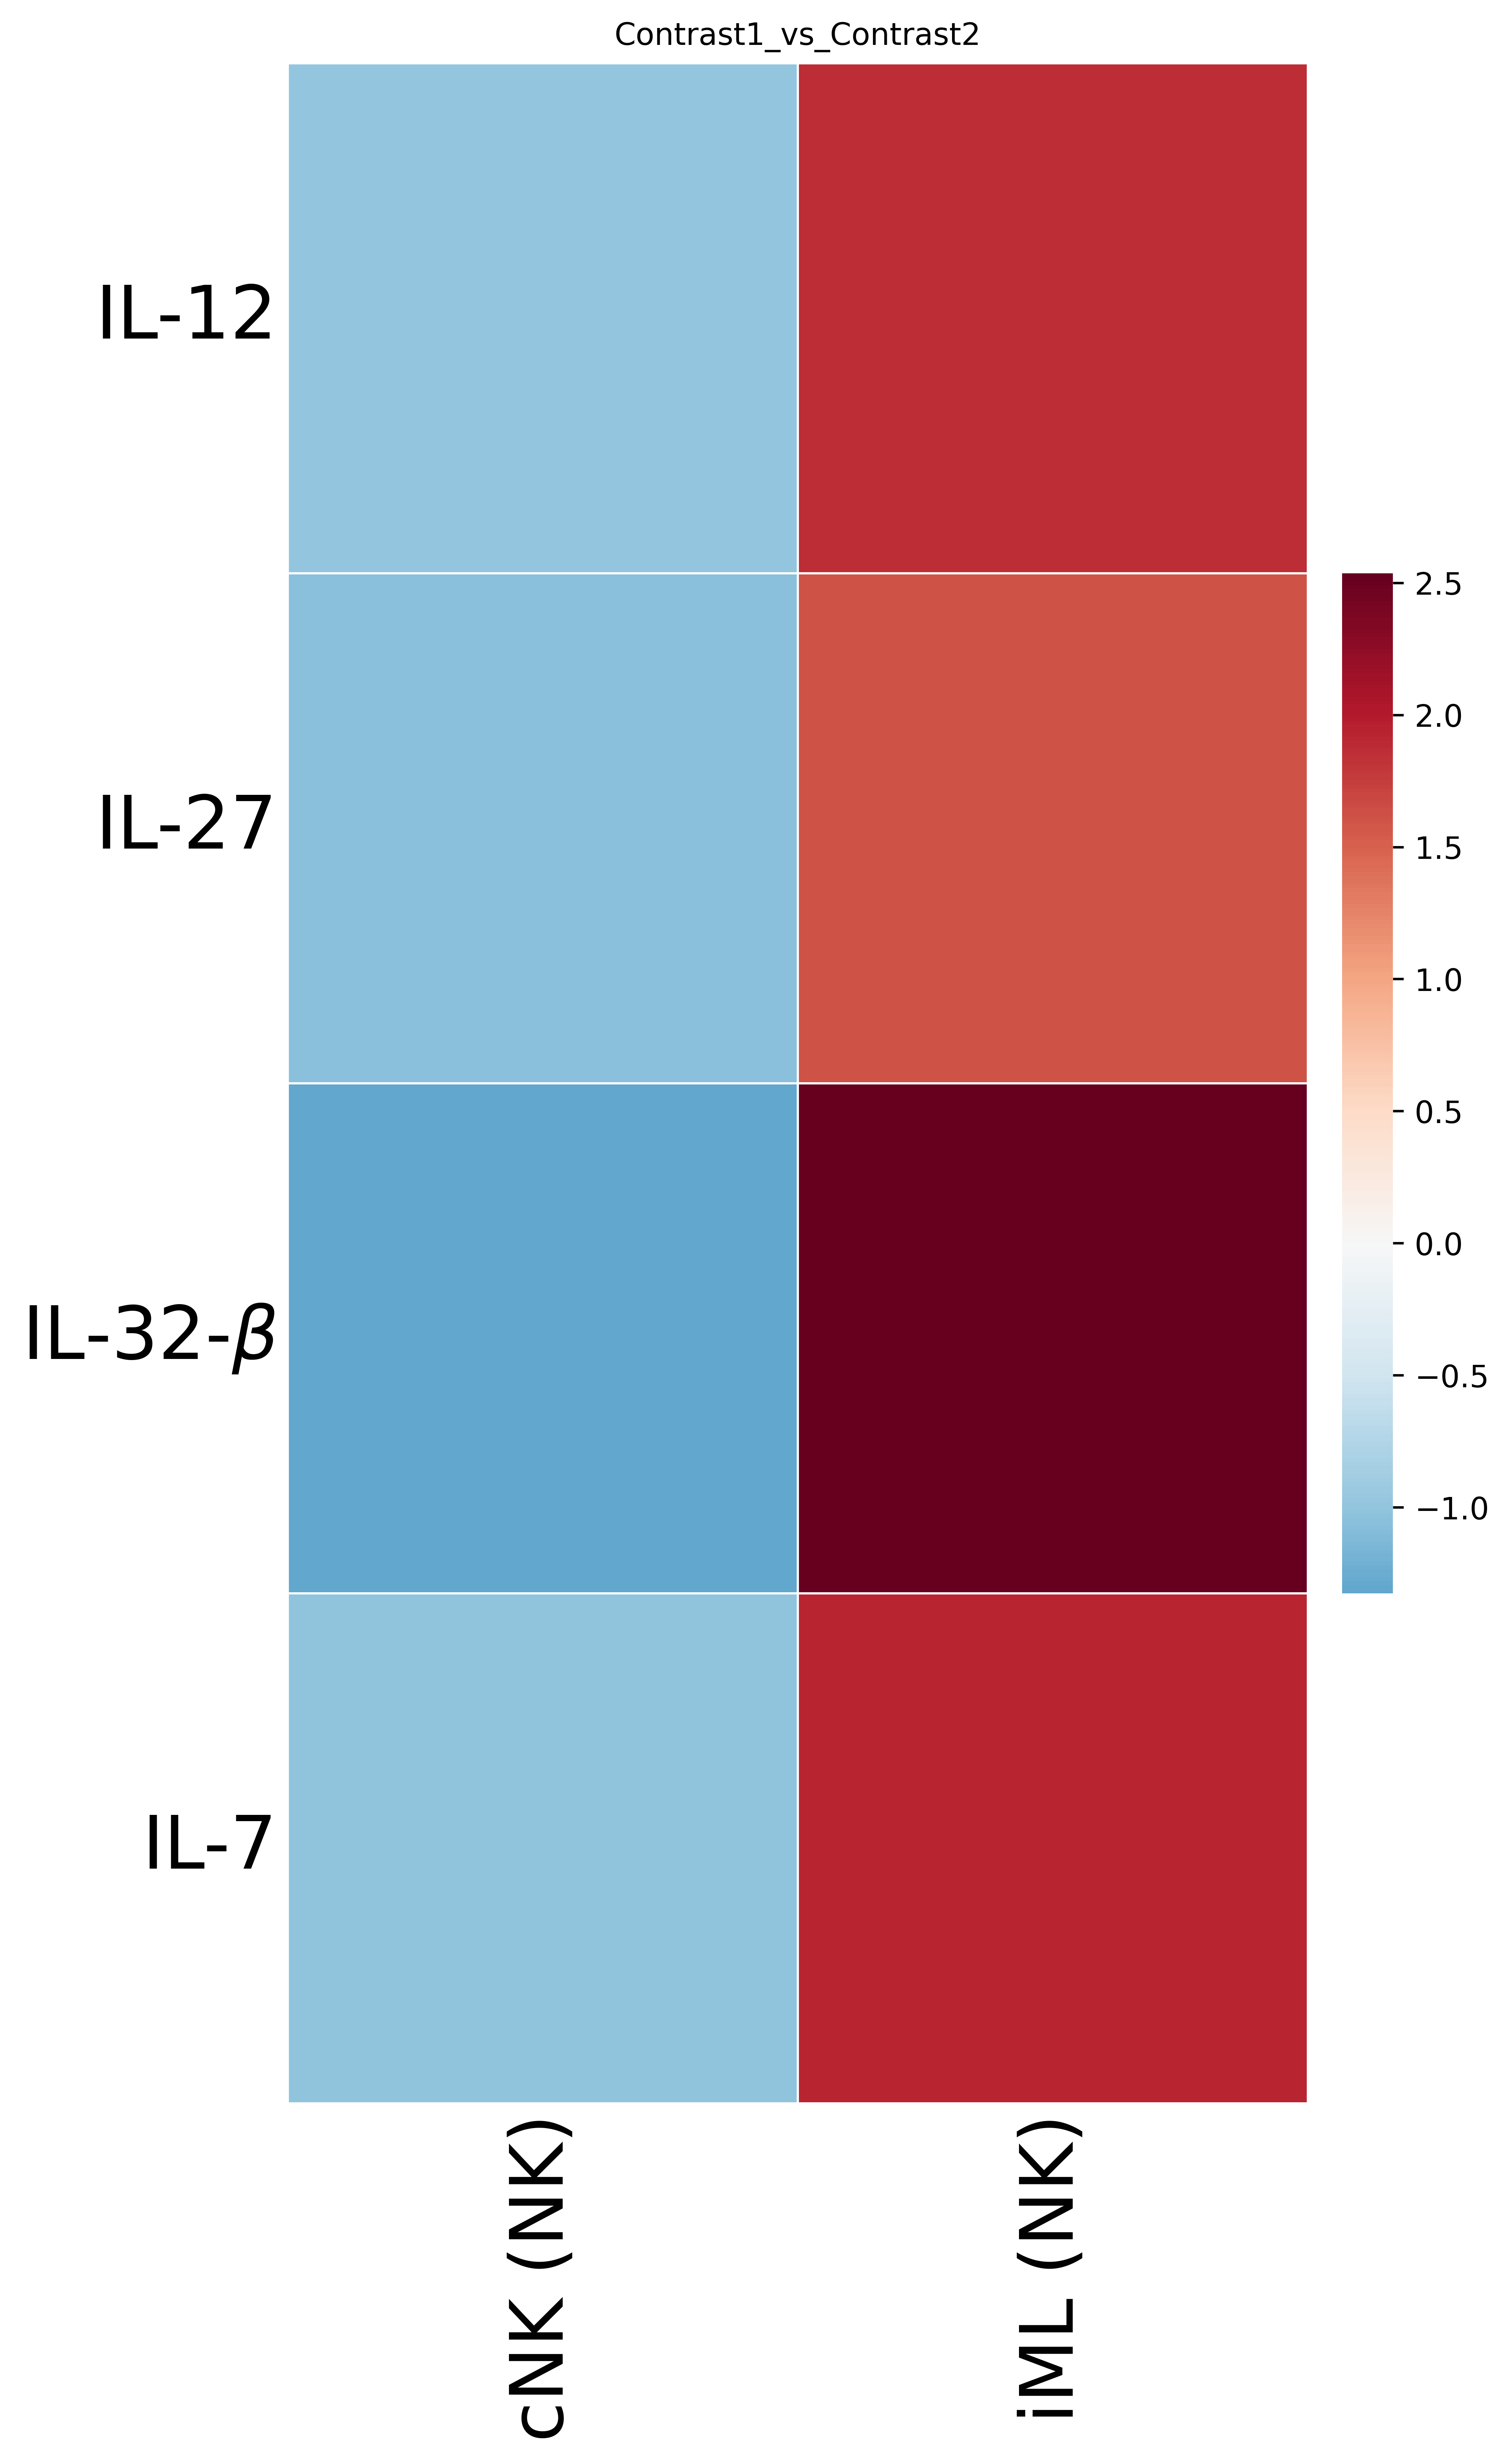

In [220]:
results_pivot=robust_results[contrast_one][0]# Check the actual cytokine names in your data
print("Available cytokines:")
print(results_pivot.index.tolist())  # or results_pivot.columns.tolist()

# Filter with case-insensitive matching
cytokines_to_plot = ['IL-32-beta', 'IL-7', 'IL-12', 'IL-27']
available_cytokines = results_pivot.index.tolist()

# Find matching cytokines
matched_cytokines = [c for c in available_cytokines 
                     if any(target.lower() in c.lower() for target in cytokines_to_plot)]

print(f"Matched cytokines: {matched_cytokines}")

results_pivot_filtered = results_pivot.loc[matched_cytokines]
df_annot = robust_results[contrast_one][1]
df_annot_filtered = df_annot.loc[matched_cytokines]
df_annot_empty = df_annot_filtered.copy()
df_annot_empty[:] = '' 
hc.plot_significant_results(
    results_pivot=results_pivot_filtered,
    df_annot=df_annot_empty,
    fontsize=24,
    save_fig=False,
    fig_path=""
)